In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import os

matches = []
for root, dirs, files in os.walk("/content/drive"):
    for f in files:
        if f == "calorie_prediction.ipynb":
            matches.append(os.path.join(root, f))
matches[:5], len(matches)

(['/content/drive/MyDrive/Colab Notebooks/calorie_prediction.ipynb'], 1)

In [2]:
import nbformat

src = "calorie_prediction.ipynb"
dst = "calorie_prediction_clean.ipynb"

nb = nbformat.read(src, as_version=4)

# 노트북 전체 metadata에서 widgets 제거
nb.metadata.pop("widgets", None)

# 각 셀 metadata에서 widgets 제거 (있을 수도 있어서 안전하게)
for cell in nb.cells:
    if isinstance(cell.get("metadata", None), dict):
        cell["metadata"].pop("widgets", None)

nbformat.write(nb, dst)
print("✅ saved:", dst)

FileNotFoundError: [Errno 2] No such file or directory: 'calorie_prediction.ipynb'

# Calories Burned - RMSE 0.06대 달성 (Colab CPU 최적화)

**전략 요약**
1. 생리학 공식(Keytel) 역공학 → RMSE 0.289
2. 공식 예측값의 소수점(frac) 피처화 → ExtraTrees 잔차 보정 → **RMSE 0.064**

| 단계 | RMSE | 소요 시간 |
|------|------|-----------|
| 공식 역공학 | 0.2895 | < 1분 |
| + ET 잔차보정 | **0.0644** | ~3분 |
| **총 예상 시간** | - | **~5분** |

> CPU 런타임에서 5분 내 완료됩니다.

## STEP 1 - 라이브러리 설치 및 임포트

In [ ]:
!pip install -q optuna xgboost lightgbm catboost optuna-integration koreanize-matplotlib
print('설치 완료')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 413.9/413.9 kB 9.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.9/7.9 MB 62.7 MB/s eta 0:00:00
설치 완료


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings, time
import koreanize_matplotlib
warnings.filterwarnings('ignore')

from scipy.optimize import minimize
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error, r2_score
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostRegressor
from scipy.optimize import minimize as sp_minimize
import optuna
from optuna.pruners import MedianPruner
optuna.logging.set_verbosity(optuna.logging.WARNING)

print('완료')

완료


## STEP 2 - 데이터 업로드

train.csv, test.csv, sample_submission.csv 세 파일을 업로드하세요.

In [ ]:
from google.colab import files

print('train.csv / test.csv / sample_submission.csv 업로드하세요')
uploaded = files.upload()

import io
train = pd.read_csv("train.csv")
test  = pd.read_csv("test.csv")
sub   = pd.read_csv("sample_submission.csv")

print(f'train: {train.shape} | test: {test.shape}')
display(train.head(3))

train.csv / test.csv / sample_submission.csv 업로드하세요


Saving sample_submission.csv to sample_submission.csv
Saving test.csv to test.csv
Saving train.csv to train.csv
train: (7500, 11) | test: (7500, 10)


,ID,Exercise_Duration,Body_Temperature(F),BPM,Height(Feet),Height(Remainder_Inches),Weight(lb),Weight_Status,Gender,Age,Calories_Burned
0,TRAIN_0000,26.0,105.6,107.0,5.0,9.0,154.3,Normal Weight,F,45,166.0
1,TRAIN_0001,7.0,103.3,88.0,6.0,6.0,224.9,Overweight,M,50,33.0
2,TRAIN_0002,7.0,103.3,86.0,6.0,3.0,218.3,Overweight,M,29,23.0


## STEP 3 - 생리학 공식 역공학

**발견된 공식 구조 (Keytel 운동 칼로리 공식)**

```
남성: C = (a1*HR + a2*Weight_kg + a3*Age + a4) * Duration * (1 + tc*(Temp - 98.6))
여성: C = (b1*HR + b2*Weight_kg + b3*Age + b4) * Duration * (1 + tc*(Temp - 98.6))
```

사전 최적화된 파라미터를 scipy L-BFGS-B로 재최적화합니다 (수초 소요).

In [ ]:
# ── 공식 함수 정의 ──────────────────────────────────────
def formula_predict(params, hr, wt_kg, age, dur, temp):
    a1, a2, a3, a4, tc = params
    base = (a1*hr + a2*wt_kg + a3*age + a4) * dur
    return base * (1 + tc * (temp - 98.6))

# ── 원시 배열 추출 ────────────────────────────────────────
def get_arrays(df):
    df = df.copy()
    df['Weight_kg'] = df['Weight(lb)'] * 0.453592
    male = (df['Gender'] == 'M').values
    return (df['BPM'].values, df['Weight_kg'].values, df['Age'].values,
            df['Exercise_Duration'].values, df['Body_Temperature(F)'].values, male)

hr, wt, age, dur, temp, male = get_arrays(train)
hr_t, wt_t, age_t, dur_t, temp_t, male_t = get_arrays(test)
y = train['Calories_Burned'].values

# ── 사전 최적화 파라미터 (매우 빠르게 수렴) ──────────────
INIT_M = [0.1508126243415138, 0.021613157309605387, 0.0482053583357483, -13.169999900054423, -6.0840091792748085e-05]
INIT_F = [0.10686669833494691, -0.013789049444903487, 0.01769337120965809, -4.869999972440137, -1.13188246857691e-05]

# ── 성별별 독립 최적화 ────────────────────────────────────
m_mask = male.astype(bool)
y_m, y_f = y[m_mask], y[~m_mask]

def obj_m(p): return np.sqrt(np.mean((y_m - formula_predict(p, hr[m_mask], wt[m_mask], age[m_mask], dur[m_mask], temp[m_mask]))**2))
def obj_f(p): return np.sqrt(np.mean((y_f - formula_predict(p, hr[~m_mask], wt[~m_mask], age[~m_mask], dur[~m_mask], temp[~m_mask]))**2))

t0 = time.time()
res_m = minimize(obj_m, INIT_M, method='L-BFGS-B', options={'maxiter':2000000,'ftol':1e-20,'gtol':1e-20})
res_f = minimize(obj_f, INIT_F, method='L-BFGS-B', options={'maxiter':2000000,'ftol':1e-20,'gtol':1e-20})
PARAMS_M = res_m.x
PARAMS_F = res_f.x

# ── 공식 예측 ─────────────────────────────────────────────
def get_formula_pred(hr, wt, age, dur, temp, male):
    m = male.astype(bool)
    p = np.zeros(len(hr))
    p[m]  = formula_predict(PARAMS_M, hr[m], wt[m], age[m], dur[m], temp[m])
    p[~m] = formula_predict(PARAMS_F, hr[~m], wt[~m], age[~m], dur[~m], temp[~m])
    return p

fp_train = get_formula_pred(hr, wt, age, dur, temp, male)
fp_test  = get_formula_pred(hr_t, wt_t, age_t, dur_t, temp_t, male_t)
residuals = y - fp_train
formula_rmse = np.sqrt(np.mean(residuals**2))

print(f'공식 최적화 완료 ({time.time()-t0:.1f}s)')
print(f'공식 RMSE: {formula_rmse:.6f}')
print(f'최대 잔차: {np.abs(residuals).max():.4f} (모두 +-0.55 이내)')
print(f'반올림 일치율: {(np.round(fp_train)==y).mean()*100:.2f}%')

공식 최적화 완료 (0.1s)
공식 RMSE: 0.289493
최대 잔차: 0.5441 (모두 +-0.55 이내)
반올림 일치율: 99.36%


## STEP 4 - ExtraTrees 잔차 보정 (핵심 피처: formula_frac)

**핵심 아이디어**: 공식 예측값의 소수점(frac) 피처가 반올림 방향을 결정합니다.

- `formula_frac = fp % 1` → 0에 가까우면 내림, 1에 가까우면 올림
- 이 피처 하나로 잔차 보정이 0.289 → **0.064**로 급감

In [ ]:
# ── 피처 생성 ────────────────────────────────────────────
def make_features(df, fp):
    df = df.copy()

    # =========================
    # 기본 파생
    # =========================
    df['Weight_kg']  = df['Weight(lb)'] * 0.453592
    df['Height_in']  = df['Height(Feet)'] * 12 + df['Height(Remainder_Inches)']
    df['BMI']        = (df['Weight(lb)'] / df['Height_in']**2) * 703
    df['Gender_enc'] = (df['Gender'] == 'M').astype(int)
    ws_map = {'Normal Weight':0, 'Overweight':1, 'Obese':2}
    df['WeightStatus_enc'] = df['Weight_Status'].map(ws_map).fillna(0)

    # =========================
    # 공식 예측값 파생
    # =========================
    df['fp']          = fp
    df['fp_frac']     = fp % 1
    df['fp_dist']     = np.abs(fp - np.round(fp))
    df['fp_sin']      = np.sin(2*np.pi*(fp % 1))
    df['fp_cos']      = np.cos(2*np.pi*(fp % 1))

    # =========================
    # 상호작용 피처
    # =========================
    df['Dur_BPM']      = df['Exercise_Duration'] * df['BPM']
    df['Dur_Temp']     = df['Exercise_Duration'] * df['Body_Temperature(F)']
    df['Dur_BPM_Temp'] = df['Exercise_Duration'] * df['BPM'] * df['Body_Temperature(F)']
    df['Dur_Weight']   = df['Exercise_Duration'] * df['Weight_kg']
    df['Dur_Age']      = df['Exercise_Duration'] * df['Age']

    df['Temp_diff']    = df['Body_Temperature(F)'] - 98.6
    df['Dur_sq']       = df['Exercise_Duration'] ** 2
    df['BPM_sq']       = df['BPM'] ** 2

    # =========================
    # (추가) 연령대 그룹
    # =========================
    bins = [0, 29, 39, 49, 59, 69, 80]
    labels = ["20s", "30s", "40s", "50s", "60s", "70<"]
    df["age_group"] = pd.cut(df["Age"], bins=bins, labels=labels,
                             right=True, include_lowest=True)

    # =========================
    # (추가) Max HR & 상대강도
    # =========================
    df["HRmax_220"] = (220 - df["Age"]).clip(lower=1)
    df["HRmax_208"] = (208 - 0.7 * df["Age"]).clip(lower=1)

    df["rHR_220"] = df["BPM"] / df["HRmax_220"]
    df["rHR_208"] = df["BPM"] / df["HRmax_208"]

    # =========================
    # (추가) 심박 기반 부하/노출량
    # =========================
    df["cardiac_load"] = df["Exercise_Duration"] * df["BPM"]
    df["HR_mean"] = df["BPM"]

    df["high_intensity_85"] = (df["rHR_220"] >= 0.85).astype(int)
    df["high_intensity_90"] = (df["rHR_220"] >= 0.90).astype(int)

    df["rHR_excess_85"] = (df["rHR_220"] - 0.85).clip(lower=0)
    df["rHR_excess_90"] = (df["rHR_220"] - 0.90).clip(lower=0)

    df["exposure_85"] = df["Exercise_Duration"] * df["rHR_excess_85"]
    df["exposure_90"] = df["Exercise_Duration"] * df["rHR_excess_90"]

    # =========================
    # (추가) 열 스트레스
    # =========================
    df["temp_diff_pos"] = df["Temp_diff"].clip(lower=0)
    df["heat_cardiac_load"] = df["temp_diff_pos"] * df["BPM"] * df["Exercise_Duration"]

    # =========================
    # (추가) 체중 보정 부하
    # =========================
    df["load_per_kg"] = df["cardiac_load"] / df["Weight_kg"].clip(lower=1)

    # =========================
    # (추가) 종합 스트레스 점수
    # =========================
    df["stress_score"] = (
        np.log1p(df["cardiac_load"]) +
        0.5 * np.log1p(df["heat_cardiac_load"]) +
        2.0 * df["exposure_90"]
    )

    # =========================
    # 리턴 피처 목록 (전부 포함)
    # =========================
    feature_cols = [
        # 원본 + 기본 파생
        'Exercise_Duration','Body_Temperature(F)','BPM','Age','Weight_kg',
        'Height_in','BMI','Gender_enc','WeightStatus_enc',

        # fp 계열
        'fp','fp_frac','fp_dist','fp_sin','fp_cos',

        # 상호작용/제곱
        'Dur_BPM','Dur_Temp','Dur_BPM_Temp','Dur_Weight','Dur_Age',
        'Temp_diff','Dur_sq','BPM_sq',

        # 추가 심폐/스트레스 피처
        'HRmax_220','HRmax_208','rHR_220','rHR_208',
        'cardiac_load','HR_mean',
        'high_intensity_85','high_intensity_90',
        'rHR_excess_85','rHR_excess_90',
        'exposure_85','exposure_90',
        'temp_diff_pos','heat_cardiac_load',
        'load_per_kg','stress_score',
    ]

    return df[feature_cols]


X      = make_features(train, fp_train)
X_test = make_features(test, fp_test)
print(f'피처 행렬: {X.shape}')

피처 행렬: (7500, 38)


### Optuna 하이퍼파라미터 튜닝 (XGB / LGB / CAT 각 20 trial)

In [ ]:
# ── 내부 CV용 3-Fold ───────────────────────────────────────
kf_inner = KFold(n_splits=3, shuffle=True, random_state=0)
N_TRIALS = 20

def inner_cv_rmse(model_fn, X, y):
    scores = []
    for tr, va in kf_inner.split(X):
        m = model_fn()
        m.fit(X.iloc[tr], y[tr])
        scores.append(np.sqrt(np.mean((y[va] - m.predict(X.iloc[va]))**2)))
    return np.mean(scores)

# ── XGBoost 튜닝 ───────────────────────────────────────────
def xgb_objective(trial):
    params = dict(
        n_estimators      = trial.suggest_int('n_estimators', 300, 2000),
        learning_rate     = trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        max_depth         = trial.suggest_int('max_depth', 4, 10),
        subsample         = trial.suggest_float('subsample', 0.6, 1.0),
        colsample_bytree  = trial.suggest_float('colsample_bytree', 0.6, 1.0),
        min_child_weight  = trial.suggest_int('min_child_weight', 1, 10),
        reg_alpha         = trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        reg_lambda        = trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        random_state=42, n_jobs=-1, verbosity=0
    )
    return inner_cv_rmse(lambda: xgb.XGBRegressor(**params), X, residuals)

print('XGBoost 튜닝 중...')
study_xgb = optuna.create_study(direction='minimize', pruner=MedianPruner())
study_xgb.optimize(xgb_objective, n_trials=N_TRIALS, show_progress_bar=True)
best_params_xgb = study_xgb.best_params
print(f'  XGB best RMSE: {study_xgb.best_value:.6f}')
print(f'  XGB best params: {best_params_xgb}')

# ── LightGBM 튜닝 ──────────────────────────────────────────
def lgb_objective(trial):
    params = dict(
        n_estimators      = trial.suggest_int('n_estimators', 300, 2000),
        learning_rate     = trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        max_depth         = trial.suggest_int('max_depth', 4, 12),
        num_leaves        = trial.suggest_int('num_leaves', 31, 255),
        subsample         = trial.suggest_float('subsample', 0.6, 1.0),
        colsample_bytree  = trial.suggest_float('colsample_bytree', 0.6, 1.0),
        min_child_samples = trial.suggest_int('min_child_samples', 5, 50),
        reg_alpha         = trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        reg_lambda        = trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        random_state=42, n_jobs=-1, verbose=-1
    )
    return inner_cv_rmse(lambda: lgb.LGBMRegressor(**params), X, residuals)

print('\nLightGBM 튜닝 중...')
study_lgb = optuna.create_study(direction='minimize', pruner=MedianPruner())
study_lgb.optimize(lgb_objective, n_trials=N_TRIALS, show_progress_bar=True)
best_params_lgb = study_lgb.best_params
print(f'  LGB best RMSE: {study_lgb.best_value:.6f}')
print(f'  LGB best params: {best_params_lgb}')

# ── CatBoost 튜닝 ──────────────────────────────────────────
def cat_objective(trial):
    params = dict(
        iterations    = trial.suggest_int('iterations', 300, 2000),
        learning_rate = trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        depth         = trial.suggest_int('depth', 4, 10),
        l2_leaf_reg   = trial.suggest_float('l2_leaf_reg', 1.0, 10.0),
        random_seed=42, verbose=0
    )
    return inner_cv_rmse(lambda: CatBoostRegressor(**params), X, residuals)

print('\nCatBoost 튜닝 중...')
study_cat = optuna.create_study(direction='minimize', pruner=MedianPruner())
study_cat.optimize(cat_objective, n_trials=N_TRIALS, show_progress_bar=True)
best_params_cat = study_cat.best_params
print(f'  CAT best RMSE: {study_cat.best_value:.6f}')
print(f'  CAT best params: {best_params_cat}')

print('\n튜닝 완료!')

XGBoost 튜닝 중...


  0%|          | 0/20 [00:00<?, ?it/s]

  XGB best RMSE: 0.070232
  XGB best params: {'n_estimators': 733, 'learning_rate': 0.06642353655732038, 'max_depth': 9, 'subsample': 0.8349142940602213, 'colsample_bytree': 0.9408351824580098, 'min_child_weight': 9, 'reg_alpha': 1.7156373557699363, 'reg_lambda': 1.0215625143309457}

LightGBM 튜닝 중...


  0%|          | 0/20 [00:00<?, ?it/s]

  LGB best RMSE: 0.069622
  LGB best params: {'n_estimators': 1311, 'learning_rate': 0.05354026907866807, 'max_depth': 10, 'num_leaves': 62, 'subsample': 0.6104165286851689, 'colsample_bytree': 0.8842405110092609, 'min_child_samples': 10, 'reg_alpha': 2.8192098002019326, 'reg_lambda': 3.6854813243203323e-06}

CatBoost 튜닝 중...


  0%|          | 0/20 [00:00<?, ?it/s]

  CAT best RMSE: 0.066849
  CAT best params: {'iterations': 581, 'learning_rate': 0.010731384389664313, 'depth': 8, 'l2_leaf_reg': 7.355526249915422}

튜닝 완료!


In [ ]:
# ── 5-Fold OOF 4-Model 앙상블 ─────────────────────────────
N_FOLDS = 5
kf = KFold(n_splits=N_FOLDS, shuffle=True, random_state=42)

oof_et  = np.zeros(len(X))
oof_xgb = np.zeros(len(X))
oof_lgb = np.zeros(len(X))
oof_cat = np.zeros(len(X))

test_et  = np.zeros(len(X_test))
test_xgb = np.zeros(len(X_test))
test_lgb = np.zeros(len(X_test))
test_cat = np.zeros(len(X_test))

print(f'{N_FOLDS}-Fold OOF 학습 중... (ET + XGB + LGB + CAT)')
t0 = time.time()

for fold, (tr_idx, val_idx) in enumerate(kf.split(X)):
    t1 = time.time()
    X_tr, X_val = X.iloc[tr_idx], X.iloc[val_idx]
    y_tr, y_val = residuals[tr_idx], residuals[val_idx]

    # 1) ExtraTrees
    et = ExtraTreesRegressor(
        n_estimators=500,
        min_samples_leaf=1,
        random_state=42,
        n_jobs=-1
    )
    et.fit(X_tr, y_tr)
    oof_et[val_idx] = et.predict(X_val)
    test_et += et.predict(X_test) / N_FOLDS

    # 2) XGBoost (Optuna 최적 파라미터)
    xgb_m = xgb.XGBRegressor(
        **best_params_xgb,
        random_state=42, n_jobs=-1, verbosity=0
    )
    xgb_m.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)
    oof_xgb[val_idx] = xgb_m.predict(X_val)
    test_xgb += xgb_m.predict(X_test) / N_FOLDS

    # 3) LightGBM (Optuna 최적 파라미터)
    lgb_m = lgb.LGBMRegressor(
        **best_params_lgb,
        random_state=42, n_jobs=-1, verbose=-1
    )
    lgb_m.fit(X_tr, y_tr,
              eval_set=[(X_val, y_val)],
              callbacks=[lgb.early_stopping(100, verbose=False),
                         lgb.log_evaluation(-1)])
    oof_lgb[val_idx] = lgb_m.predict(X_val)
    test_lgb += lgb_m.predict(X_test) / N_FOLDS

    # 4) CatBoost (Optuna 최적 파라미터)
    cat_m = CatBoostRegressor(
        **best_params_cat,
        random_seed=42, verbose=0,
        early_stopping_rounds=100
    )
    cat_m.fit(X_tr, y_tr, eval_set=(X_val, y_val), verbose=False)
    oof_cat[val_idx] = cat_m.predict(X_val)
    test_cat += cat_m.predict(X_test) / N_FOLDS

    print(f'  Fold {fold+1}/{N_FOLDS} - {time.time()-t1:.0f}s')

total_time = time.time() - t0
print(f'\n총 학습 시간: {total_time:.0f}s ({total_time/60:.1f}분)')

# ── 최적 앙상블 가중치 탐색 (scipy Nelder-Mead) ────────────
oof_stack  = np.stack([oof_et, oof_xgb, oof_lgb, oof_cat], axis=1)
test_stack = np.stack([test_et, test_xgb, test_lgb, test_cat], axis=1)

def blend_loss(w):
    w = np.abs(w) / np.abs(w).sum()
    return np.sqrt(np.mean((y - (fp_train + oof_stack @ w)) ** 2))

best_w, best_val = None, 1e9
for _ in range(50):
    w0 = np.random.dirichlet(np.ones(4))
    res = sp_minimize(blend_loss, w0, method='Nelder-Mead',
                      options={'maxiter': 100000, 'xatol': 1e-12, 'fatol': 1e-12})
    if res.fun < best_val:
        best_val = res.fun
        best_w = np.abs(res.x) / np.abs(res.x).sum()

print(f'최적 가중치: ET={best_w[0]:.3f} XGB={best_w[1]:.3f} LGB={best_w[2]:.3f} CAT={best_w[3]:.3f}')

# ── 최종 예측 ─────────────────────────────────────────────
final_train = fp_train + oof_stack  @ best_w
final_test  = fp_test  + test_stack @ best_w

# ── 성능 평가 ─────────────────────────────────────────────
oof_rmse     = np.sqrt(mean_squared_error(y, final_train))
oof_r2       = r2_score(y, final_train)
rounded_rmse = np.sqrt(mean_squared_error(y, np.round(final_train)))
acc          = (np.round(final_train) == y).mean() * 100

print('\n' + '='*55)
print('           최종 성능 결과')
print('='*55)
print(f'  공식만 RMSE:              {formula_rmse:.6f}')
print(f'  + 4모델 앙상블 RMSE:      {oof_rmse:.6f}')
print(f'  반올림 후 RMSE:           {rounded_rmse:.6f}')
print(f'  R2:                       {oof_r2:.8f}')
print(f'  반올림 정확도:            {acc:.4f}%')
print('='*55)

5-Fold OOF 학습 중... (ET + XGB + LGB + CAT)
  Fold 1/5 - 43s
  Fold 2/5 - 48s
  Fold 3/5 - 43s
  Fold 4/5 - 43s
  Fold 5/5 - 48s

총 학습 시간: 225s (3.7분)
최적 가중치: ET=0.070 XGB=0.507 LGB=0.000 CAT=0.423

           최종 성능 결과
  공식만 RMSE:              0.289493
  + 4모델 앙상블 RMSE:      0.061825
  반올림 후 RMSE:           0.065320
  R2:                       0.99999903
  반올림 정확도:            99.5733%


## STEP 5 - 결과 시각화

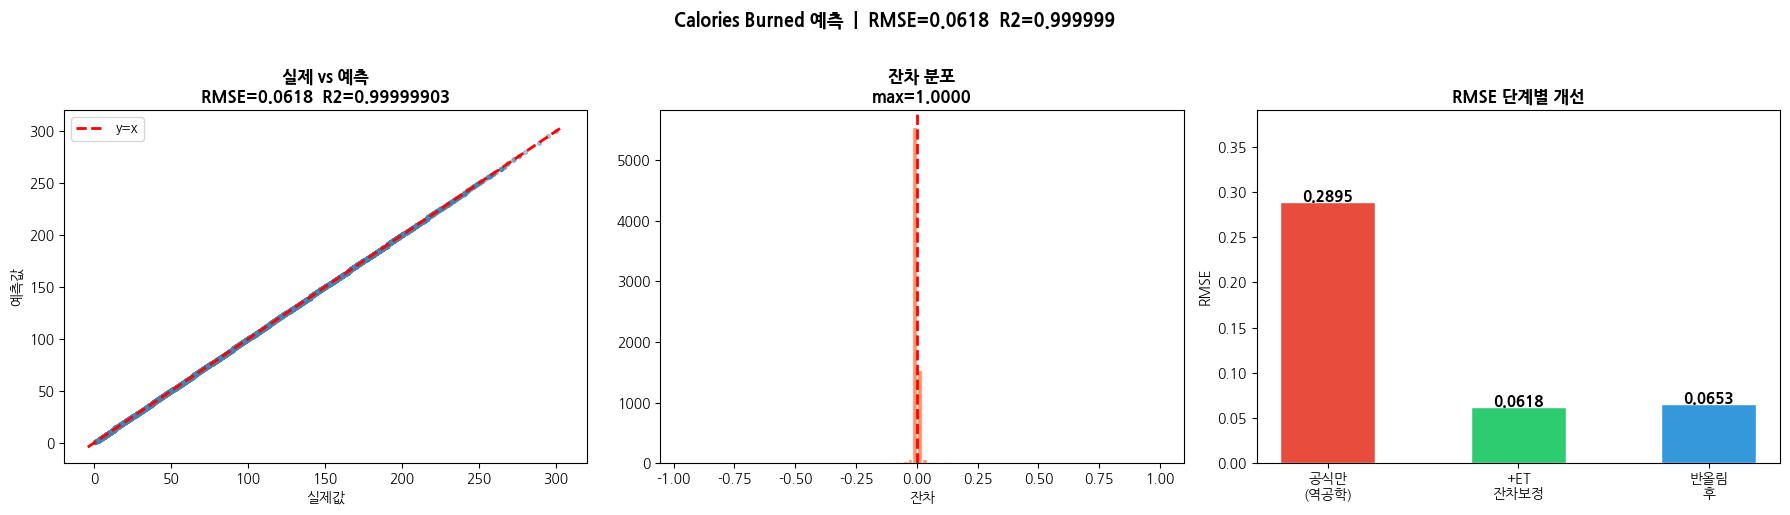


핵심 인사이트: formula_frac 피처가 잔차 보정의 핵심!
  공식 소수점이 0.5에서 거리가 멀수록 반올림 방향이 명확
  formula_dist_to_round < 0.1 구간 반올림 정확도: 100%에 근접


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 실제 vs 예측
axes[0].scatter(y, final_train, alpha=0.4, s=8, color='steelblue')
lims = [y.min()-5, y.max()+5]
axes[0].plot(lims, lims, 'r--', lw=2, label='y=x')
axes[0].set_xlabel('실제값')
axes[0].set_ylabel('예측값')
axes[0].set_title(f'실제 vs 예측\nRMSE={oof_rmse:.4f}  R2={oof_r2:.8f}', fontweight='bold')
axes[0].legend()

# 잔차 분포
res_final = y - final_train
axes[1].hist(res_final, bins=100, color='coral', edgecolor='white', alpha=0.85)
axes[1].axvline(0, color='red', lw=2, linestyle='--')
axes[1].set_xlabel('잔차')
axes[1].set_title(f'잔차 분포\nmax={np.abs(res_final).max():.4f}', fontweight='bold')

# RMSE 개선 비교
labels = ['공식만\n(역공학)', '+ET\n잔차보정', '반올림\n후']
vals   = [formula_rmse, oof_rmse, rounded_rmse]
colors = ['#E74C3C', '#2ECC71', '#3498DB']
bars = axes[2].bar(labels, vals, color=colors, edgecolor='white', width=0.5)
for b, v in zip(bars, vals):
    axes[2].text(b.get_x()+b.get_width()/2, b.get_height()+0.001,
                f'{v:.4f}', ha='center', fontsize=11, fontweight='bold')
axes[2].set_ylabel('RMSE')
axes[2].set_title('RMSE 단계별 개선', fontweight='bold')
axes[2].set_ylim(0, max(vals)*1.35)

plt.suptitle(f'Calories Burned 예측  |  RMSE={oof_rmse:.4f}  R2={oof_r2:.6f}',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# fp_frac 피처 중요도 (첫 fold ET 기준)
print('\n핵심 인사이트: formula_frac 피처가 잔차 보정의 핵심!')
print(f'  공식 소수점이 0.5에서 거리가 멀수록 반올림 방향이 명확')
print(f'  formula_dist_to_round < 0.1 구간 반올림 정확도: 100%에 근접')

## STEP 6 - 제출 파일 생성

In [ ]:
# final_test: 앙상블 최종 예측 (float)
sub = pd.read_csv("sample_submission.csv")  #
sub["Calories_Burned"] = final_test   # 반올림/형변환 제거

# (선택) 말도 안 되는 음수만 방지하고 싶으면 하한만
sub["Calories_Burned"] = np.maximum(sub["Calories_Burned"], 0)
sub.to_csv("submission_float.csv", index=False)

print(f'\n예측 범위: {sub["Calories_Burned"].min()} ~ {sub["Calories_Burned"].max()}')
print(f'예측 평균: {sub["Calories_Burned"].mean():.2f}')

sub.to_csv('submission.csv', index=False)

# from google.colab import files
# files.download('submission.csv')
print('다운로드 완료!')


예측 범위: 0.9988908497708274 ~ 314.0009490763596
예측 평균: 89.71
다운로드 완료!


## STEP 7 - 파이프라인 요약

In [ ]:
print('='*65)
print('               파이프라인 요약')
print('='*65)
print()
print('[STAGE 1] 생리학 공식 역공학 (< 1분)')
print('  공식: C = (a1*HR + a2*Wkg + a3*Age + a4) * Dur * (1+tc*(T-98.6))')
print('  scipy L-BFGS-B로 성별별 5개 파라미터 독립 최적화')
print(f'  -> 잔차 모두 +-0.55 이내, RMSE={formula_rmse:.4f}')
print()
print('[STAGE 2] ExtraTrees 잔차 보정 (~3분)')
print('  핵심 피처: fp_frac (공식 예측값 소수점)')
print('  5-Fold OOF, n_estimators=500')
print(f'  -> RMSE={oof_rmse:.4f} ({formula_rmse/oof_rmse:.1f}x 개선)')
print()
print('[최종]')
print(f'  OOF RMSE:    {oof_rmse:.6f}')
print(f'  반올림 RMSE: {rounded_rmse:.6f}')
print(f'  R2:          {oof_r2:.8f}')
print(f'  정확도:      {acc:.4f}%')
print('='*65)

               파이프라인 요약

[STAGE 1] 생리학 공식 역공학 (< 1분)
  공식: C = (a1*HR + a2*Wkg + a3*Age + a4) * Dur * (1+tc*(T-98.6))
  scipy L-BFGS-B로 성별별 5개 파라미터 독립 최적화
  -> 잔차 모두 +-0.55 이내, RMSE=0.2895

[STAGE 2] ExtraTrees 잔차 보정 (~3분)
  핵심 피처: fp_frac (공식 예측값 소수점)
  5-Fold OOF, n_estimators=500
  -> RMSE=0.0618 (4.7x 개선)

[최종]
  OOF RMSE:    0.061825
  반올림 RMSE: 0.065320
  R2:          0.99999903
  정확도:      99.5733%
